## Load dataset

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy.stats import zscore

# Load the dataset
file_path = "/Users/yiwenma/Desktop/8888 project  course/Raw_data.csv"
df = pd.read_csv(file_path)

## Dataset Overview and Summary Statistics

In [9]:
# Display basic dataset
df.info()

# Count for rows and columns
num_rows, num_columns = df.shape
print(f"Number of Rows: {num_rows}")
print(f"Number of Columns: {num_columns}")

# Display the column names and data types
print("Column Data Types:\n", df.dtypes)

# Summary the statistics for numerical & categorical variables
print("General Statistics:\n", df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1655 entries, 0 to 1654
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Series Name    1652 non-null   object
 1   Series Code    1650 non-null   object
 2   Country Name   1650 non-null   object
 3   Country Code   1650 non-null   object
 4   2002 [YR2002]  1650 non-null   object
 5   2003 [YR2003]  1650 non-null   object
 6   2004 [YR2004]  1650 non-null   object
 7   2005 [YR2005]  1650 non-null   object
 8   2006 [YR2006]  1650 non-null   object
 9   2007 [YR2007]  1650 non-null   object
 10  2008 [YR2008]  1650 non-null   object
 11  2009 [YR2009]  1650 non-null   object
 12  2010 [YR2010]  1650 non-null   object
 13  2011 [YR2011]  1650 non-null   object
 14  2012 [YR2012]  1650 non-null   object
 15  2013 [YR2013]  1650 non-null   object
 16  2014 [YR2014]  1650 non-null   object
 17  2015 [YR2015]  1650 non-null   object
 18  2016 [YR2016]  1650 non-null

## Missing data

In [10]:
# Missing values
print("Missing Values Count:\n", df.isnull().sum())

# Display the first few rows for preview
print("Dataset Preview:\n", df.head())

Missing Values Count:
 Series Name      3
Series Code      5
Country Name     5
Country Code     5
2002 [YR2002]    5
2003 [YR2003]    5
2004 [YR2004]    5
2005 [YR2005]    5
2006 [YR2006]    5
2007 [YR2007]    5
2008 [YR2008]    5
2009 [YR2009]    5
2010 [YR2010]    5
2011 [YR2011]    5
2012 [YR2012]    5
2013 [YR2013]    5
2014 [YR2014]    5
2015 [YR2015]    5
2016 [YR2016]    5
2017 [YR2017]    5
2018 [YR2018]    5
2019 [YR2019]    5
2020 [YR2020]    5
2021 [YR2021]    5
dtype: int64
Dataset Preview:
                                 Series Name     Series Code   Country Name  \
0  Fertility rate, total (births per woman)  SP.DYN.TFRT.IN  United States   
1  Fertility rate, total (births per woman)  SP.DYN.TFRT.IN        Germany   
2  Fertility rate, total (births per woman)  SP.DYN.TFRT.IN          Japan   
3  Fertility rate, total (births per woman)  SP.DYN.TFRT.IN         Norway   
4  Fertility rate, total (births per woman)  SP.DYN.TFRT.IN      Australia   

  Country Code 2002 [

In [21]:
#Fill missing values: Numerical with median, categorical with mode
df.fillna(df.median(numeric_only=True), inplace=True)  
df.fillna(df.mode().iloc[0], inplace=True)  

# Data Cleaning and Transformation
# Convert object columns to numeric where applicable
for col in df.select_dtypes(include=['object']).columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Standardizing column names (removing spaces, special characters)
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace(r'[^\w]', '', regex=True)

# Checking for Duplicates
print("\nChecking for Duplicates ")
duplicate_count = df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicate_count}")
df.drop_duplicates(inplace=True)  


Checking for Duplicates 
Number of Duplicate Rows: 0



Exploring Data Distributions


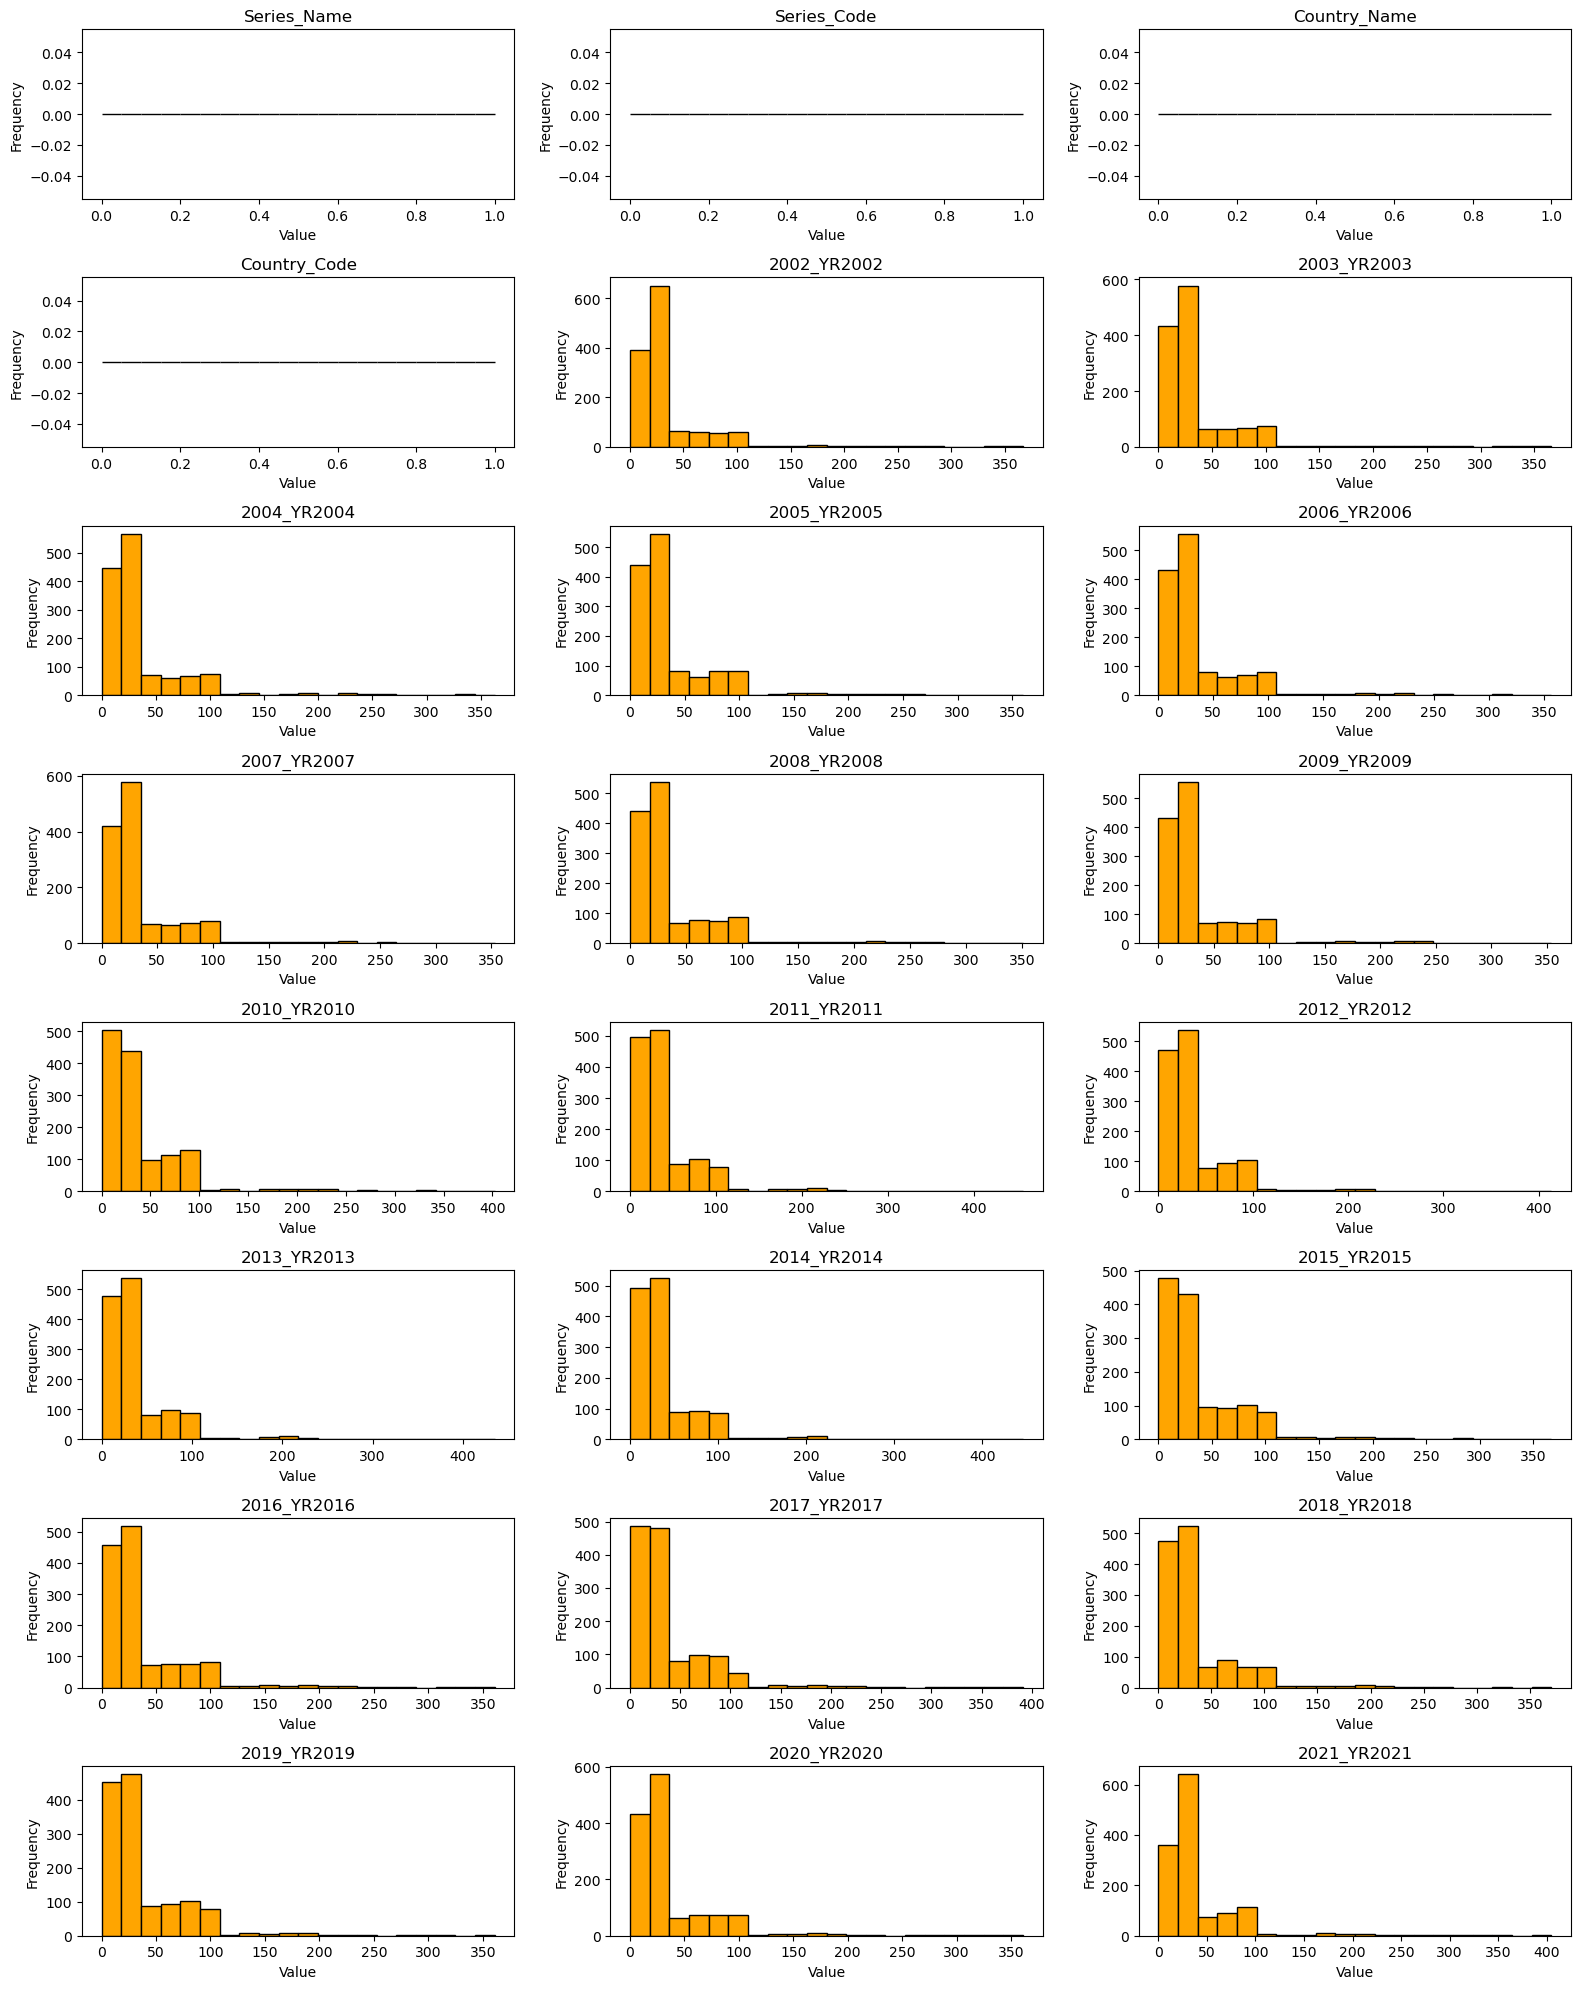

In [23]:
# SECTION 5: Exploring Data Distributions
print("\nExploring Data Distributions")
# Improved visualization for data distributions with better layout and readability
numerical_columns = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(16, 20))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot((len(numerical_columns) + 2) // 3, 3, i) 
    df[column].hist(bins=20, edgecolor='black', color='orange') 
    plt.title(column, fontsize=12)  
    plt.xlabel('Value', fontsize=10)  
    plt.ylabel('Frequency', fontsize=10)
    plt.grid(False)  
plt.tight_layout()  
plt.show()


# Correlation Analysis #


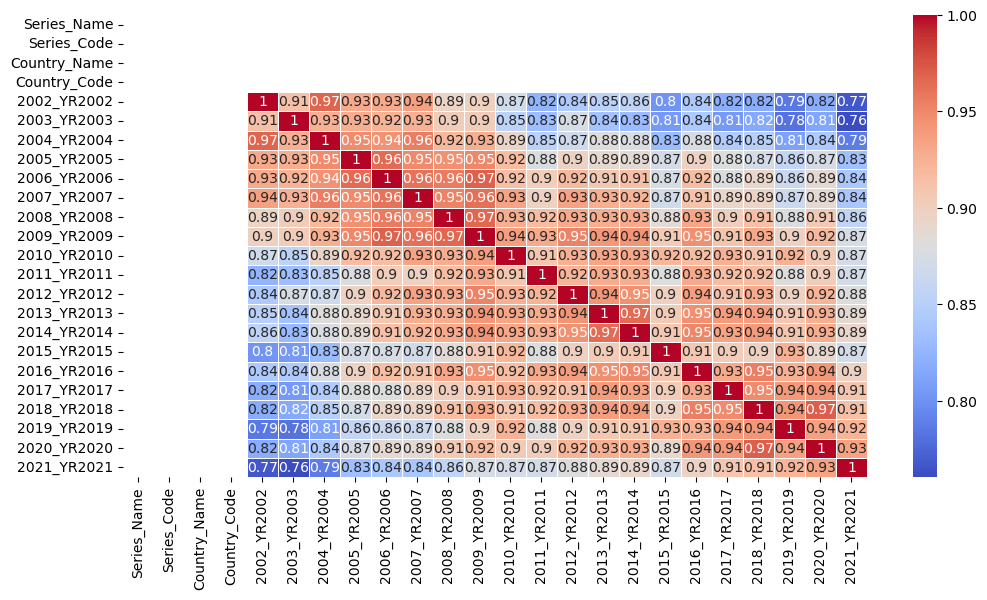


# Detecting and Handling Outliers #
Number of Outlier Rows Detected: 52

# Cleaned Dataset Preview #
   Series_Name  Series_Code  Country_Name  Country_Code  2002_YR2002  \
0          NaN          NaN           NaN           NaN       2.0205   
1          NaN          NaN           NaN           NaN       1.3400   
2          NaN          NaN           NaN           NaN       1.3200   
3          NaN          NaN           NaN           NaN       1.7500   
4          NaN          NaN           NaN           NaN       1.7560   

   2003_YR2003  2004_YR2004  2005_YR2005  2006_YR2006  2007_YR2007  ...  \
0       2.0475       2.0515        2.057        2.108        2.120  ...   
1       1.3400       1.3600        1.340        1.330        1.370  ...   
2       1.2900       1.2900        1.260        1.320        1.340  ...   
3       1.8000       1.8300        1.840        1.900        1.900  ...   
4       1.7480       1.7680        1.807        1.908        1.959  ...   

   2012_YR2012

In [24]:
# Correlation Analysis
print("\n# Correlation Analysis #")
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.show()

# Detecting and Handling Outliers
print("\n# Detecting and Handling Outliers #")
z_scores = np.abs(df.select_dtypes(include=[np.number]).apply(zscore))
outlier_rows = (z_scores > 3).any(axis=1)
outlier_count = outlier_rows.sum()
print(f"Number of Outlier Rows Detected: {outlier_count}")

df = df[~outlier_rows]

# Display cleaned dataset preview
print("\n# Cleaned Dataset Preview #")
print(df.head()) 

# Cleaned dataset
df.to_csv("Cleaned_Dataset.csv", index=False)